# Root Annotation Comparison


In [1]:
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
from pathlib import Path
from PIL import Image
import cv2

## Functions

In [2]:
def load_single_rsml(rsml_path):
    """Load a single RSML file and extract basic root information."""
    rsml_path = Path(rsml_path)
    tree = ET.parse(rsml_path)
    root_elem = tree.getroot()
    
    results = []
    
    for root in root_elem.findall('.//root'):
        root_id = root.get('ID')
        label = root.get('label')
        
        length_elem = root.find('.//properties/length')
        length_cm = float(length_elem.text) if length_elem is not None else None
        length_mm = length_cm * 10 if length_cm is not None else None
        
        points = []
        polyline = root.find('.//geometry/polyline')
        if polyline is not None:
            for point in polyline.findall('point'):
                x = float(point.get('x'))
                y = float(point.get('y'))
                points.append((x, y))
        
        start_x, start_y = points[0] if points else (None, None)
        end_x, end_y = points[-1] if points else (None, None)
        
        results.append({
            'root_id': root_id,
            'label': label,
            'length_cm': length_cm,
            'length_mm': length_mm,
            'num_points': len(points),
            'start_x': start_x,
            'start_y': start_y,
            'end_x': end_x,
            'end_y': end_y,
            'points': points
        })
    
    return pd.DataFrame(results)




In [3]:
# ==================== MASK GENERATION ====================

def extract_root_with_diameter(root_element):
    """Extract polyline points and diameter values from a root element."""
    root_id = root_element.get('ID')
    label = root_element.get('label')
    
    points = []
    polyline = root_element.find('.//geometry/polyline')
    if polyline is not None:
        for point in polyline.findall('point'):
            x = float(point.get('x'))
            y = float(point.get('y'))
            points.append((x, y))
    
    diameters = []
    diameter_func = root_element.find(".//function[@name='diameter']")
    if diameter_func is not None:
        for sample in diameter_func.findall('sample'):
            diameters.append(float(sample.text))
    
    return {
        'root_id': root_id,
        'label': label,
        'points': points,
        'diameters': diameters
    }


def get_image_dimensions(rsml_path, image_dir=None):
    """Get image dimensions by loading the corresponding PNG file."""
    rsml_path = Path(rsml_path)
    
    if image_dir is not None:
        image_path = Path(image_dir) / rsml_path.with_suffix('.png').name
    else:
        image_path = rsml_path.with_suffix('.png')
    
    if not image_path.exists():
        print(f"Warning: Image file not found: {image_path}")
        return None
    
    img = Image.open(image_path)
    width, height = img.size
    return height, width


def create_root_mask(points, diameters, img_shape, line_thickness=2):
    """Create a binary mask from polyline points."""
    mask = np.zeros(img_shape, dtype=np.uint8)
    
    if len(points) < 2:
        return mask
    
    pts = np.array(points, dtype=np.int32)
    cv2.polylines(mask, [pts], False, 255, thickness=line_thickness)
    
    return mask


def create_masks_from_rsml(rsml_path, line_thickness=2, image_dir=None):
    """Create binary masks from RSML file."""
    rsml_path = Path(rsml_path)
    
    img_shape = get_image_dimensions(rsml_path, image_dir=image_dir)
    if img_shape is None:
        raise ValueError(f"Cannot find corresponding image file for {rsml_path}")
    
    tree = ET.parse(rsml_path)
    root_elem = tree.getroot()
    
    individual_masks = {}
    combined_mask = np.zeros(img_shape, dtype=np.uint8)
    
    for root in root_elem.findall('.//root'):
        root_data = extract_root_with_diameter(root)
        label = root_data['label']
        
        mask = create_root_mask(
            root_data['points'], 
            root_data['diameters'], 
            img_shape,
            line_thickness
        )
        
        individual_masks[label] = mask
        combined_mask = cv2.bitwise_or(combined_mask, mask)
    
    return {
        'individual_masks': individual_masks,
        'combined_mask': combined_mask,
        'img_shape': img_shape
    }




In [4]:
# ==================== BATCH LOADING ====================

def load_all_annotators_with_masks(parent_dir, image_dir, line_thickness=2):
    """Load RSML data from all annotator subdirectories and generate masks."""
    parent_dir = Path(parent_dir)
    image_dir = Path(image_dir)
    
    all_data = []
    subdirs = sorted([d for d in parent_dir.iterdir() if d.is_dir()])
    
    print(f"Found {len(subdirs)} annotator directories")
    
    for subdir in subdirs:
        annotator_id = subdir.name.split('_')[0]
        rsml_files = sorted(subdir.glob('*.rsml'))
        
        print(f"  Loading {annotator_id}: {len(rsml_files)} files...", end=" ")
        
        for rsml_file in rsml_files:
            df = load_single_rsml(rsml_file)
            df['annotator'] = annotator_id
            df['filename'] = rsml_file.name
            
            try:
                masks = create_masks_from_rsml(rsml_file, line_thickness=line_thickness, image_dir=image_dir)
                
                mask_list = []
                for idx, row in df.iterrows():
                    label = row['label']
                    if label in masks['individual_masks']:
                        mask_list.append(masks['individual_masks'][label])
                    else:
                        mask_list.append(None)
                
                df['mask'] = mask_list
                        
            except Exception as e:
                print(f"\n    Skipping masks for {rsml_file.name}: {e}")
                df['mask'] = None
            
            all_data.append(df)
        
        print("OK")
    
    combined = pd.concat(all_data, ignore_index=True)
    
    cols = ['annotator', 'filename', 'label', 'length_mm', 'num_points',
            'start_x', 'start_y', 'end_x', 'end_y',
            'length_cm', 'root_id', 'points']
    
    if 'mask' in combined.columns:
        cols.append('mask')
    
    combined = combined[cols]
    
    print(f"\nTotal: {len(combined)} roots from {combined['annotator'].nunique()} annotators")
    
    return combined




In [5]:
# ==================== FILTERING ====================

def filter_primary_roots(df):
    """Filter dataframe to only primary roots (root_01 through root_05)."""
    valid_labels = ['root_01', 'root_02', 'root_03', 'root_04', 'root_05']
    return df[df['label'].isin(valid_labels)].copy()




In [6]:
# ==================== VALIDATION ====================

def check_invalid_labels(df, valid_labels=['root_01', 'root_02', 'root_03', 'root_04', 'root_05']):
    """Find files with invalid root labels."""
    problems = []
    
    for filename in df['filename'].unique():
        file_data = df[df['filename'] == filename]
        
        for annotator in file_data['annotator'].unique():
            ann_data = file_data[file_data['annotator'] == annotator]
            labels = ann_data['label'].tolist()
            
            invalid = [l for l in labels if l not in valid_labels]
            
            if invalid:
                problems.append({
                    'annotator': annotator,
                    'filename': filename,
                    'invalid_labels': invalid,
                    'all_labels': labels
                })
    
    return pd.DataFrame(problems)


def check_primary_root_completeness(df):
    """Check if all 5 primary roots are present for each file/annotator."""
    expected_labels = ['root_01', 'root_02', 'root_03', 'root_04', 'root_05']
    problems = []
    
    df_primary = filter_primary_roots(df)
    
    for filename in df_primary['filename'].unique():
        file_data = df_primary[df_primary['filename'] == filename]
        
        for annotator in file_data['annotator'].unique():
            ann_data = file_data[file_data['annotator'] == annotator]
            present_labels = set(ann_data['label'].tolist())
            missing_labels = [l for l in expected_labels if l not in present_labels]
            
            if missing_labels:
                problems.append({
                    'annotator': annotator,
                    'filename': filename,
                    'missing': missing_labels,
                    'present': sorted(present_labels)
                })
    
    return pd.DataFrame(problems)




In [7]:
# ==================== COMPARISON ====================

def compare_primary_roots_pairwise(df):
    """Compare primary root lengths between all pairs of annotators."""
    df_primary = filter_primary_roots(df)
    
    comparisons = []
    
    for filename in df_primary['filename'].unique():
        file_data = df_primary[df_primary['filename'] == filename]
        annotators = sorted(file_data['annotator'].unique())
        
        for i, ann_a in enumerate(annotators):
            for ann_b in annotators[i+1:]:
                data_a = file_data[file_data['annotator'] == ann_a].set_index('label')
                data_b = file_data[file_data['annotator'] == ann_b].set_index('label')
                
                common_labels = set(data_a.index) & set(data_b.index)
                
                for label in sorted(common_labels):
                    length_a = data_a.loc[label, 'length_mm']
                    length_b = data_b.loc[label, 'length_mm']
                    
                    diff = length_a - length_b
                    abs_diff = abs(diff)
                    pct_diff = 100 * diff / length_b if length_b != 0 else None
                    
                    comparisons.append({
                        'filename': filename,
                        'label': label,
                        'annotator_a': ann_a,
                        'annotator_b': ann_b,
                        'length_a': length_a,
                        'length_b': length_b,
                        'diff': diff,
                        'abs_diff': abs_diff,
                        'pct_diff': pct_diff
                    })
    
    return pd.DataFrame(comparisons)


In [8]:
def calculate_mask_metrics(mask_a, mask_b):
    """
    Calculate Dice coefficient and IoU between two masks.
    
    Returns:
    --------
    dict with 'dice' and 'iou' scores (0-1)
    """
    if mask_a is None or mask_b is None:
        return {'dice': None, 'iou': None}
    
    intersection = np.logical_and(mask_a > 0, mask_b > 0).sum()
    union = np.logical_or(mask_a > 0, mask_b > 0).sum()
    sum_areas = (mask_a > 0).sum() + (mask_b > 0).sum()
    
    iou = intersection / union if union > 0 else 0
    dice = (2 * intersection) / sum_areas if sum_areas > 0 else 0
    
    return {'dice': dice, 'iou': iou}


def compare_primary_roots_with_masks(df):
    """
    Compare primary root lengths AND masks between all pairs of annotators.
    """
    df_primary = filter_primary_roots(df)
    
    comparisons = []
    
    for filename in df_primary['filename'].unique():
        file_data = df_primary[df_primary['filename'] == filename]
        annotators = sorted(file_data['annotator'].unique())
        
        for i, ann_a in enumerate(annotators):
            for ann_b in annotators[i+1:]:
                data_a = file_data[file_data['annotator'] == ann_a].set_index('label')
                data_b = file_data[file_data['annotator'] == ann_b].set_index('label')
                
                common_labels = set(data_a.index) & set(data_b.index)
                
                for label in sorted(common_labels):
                    length_a = data_a.loc[label, 'length_mm']
                    length_b = data_b.loc[label, 'length_mm']
                    mask_a = data_a.loc[label, 'mask'] if 'mask' in data_a.columns else None
                    mask_b = data_b.loc[label, 'mask'] if 'mask' in data_b.columns else None
                    
                    diff = length_a - length_b
                    abs_diff = abs(diff)
                    pct_diff = 100 * diff / length_b if length_b != 0 else None
                    
                    # Calculate mask metrics
                    mask_metrics = calculate_mask_metrics(mask_a, mask_b)
                    
                    comparisons.append({
                        'filename': filename,
                        'label': label,
                        'annotator_a': ann_a,
                        'annotator_b': ann_b,
                        'length_a': length_a,
                        'length_b': length_b,
                        'diff': diff,
                        'abs_diff': abs_diff,
                        'pct_diff': pct_diff,
                        'dice': mask_metrics['dice'],
                        'iou': mask_metrics['iou']
                    })
    
    return pd.DataFrame(comparisons)

In [9]:
def visualize_mask_comparison(df, filename, label, annotator_a, annotator_b, image_dir, padding=50):
    """
    Visualize mask comparison with zoom to annotation region.
    Shows box on original image indicating zoom area.
    """
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    
    # Get the data
    df_primary = filter_primary_roots(df)
    file_data = df_primary[df_primary['filename'] == filename]
    
    data_a = file_data[file_data['annotator'] == annotator_a]
    data_a = data_a[data_a['label'] == label]
    
    data_b = file_data[file_data['annotator'] == annotator_b]
    data_b = data_b[data_b['label'] == label]
    
    if len(data_a) == 0 or len(data_b) == 0:
        print(f"No data found for {filename}, {label}")
        return
    
    mask_a = data_a.iloc[0]['mask']
    mask_b = data_b.iloc[0]['mask']
    length_a = data_a.iloc[0]['length_mm']
    length_b = data_b.iloc[0]['length_mm']
    
    # Load original image
    img_path = Path(image_dir) / filename.replace('.rsml', '.png')
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE)
    
    # Calculate metrics
    metrics = calculate_mask_metrics(mask_a, mask_b)
    
    # Find bounding box of both masks combined
    combined_mask = cv2.bitwise_or(mask_a, mask_b)
    coords = np.column_stack(np.where(combined_mask > 0))
    
    if len(coords) == 0:
        print(f"No mask data for {filename}, {label}")
        return
    
    # Get bounding box with padding
    min_y, min_x = coords.min(axis=0)
    max_y, max_x = coords.max(axis=0)
    
    min_y = max(0, min_y - padding)
    max_y = min(img.shape[0], max_y + padding)
    min_x = max(0, min_x - padding)
    max_x = min(img.shape[1], max_x + padding)
    
    # Crop regions
    img_crop = img[min_y:max_y, min_x:max_x]
    mask_a_crop = mask_a[min_y:max_y, min_x:max_x]
    mask_b_crop = mask_b[min_y:max_y, min_x:max_x]
    
    # Create visualization
    fig, axes = plt.subplots(2, 2, figsize=(14, 14))
    
    # Original image with box
    axes[0, 0].imshow(img, cmap='gray')
    rect = Rectangle((min_x, min_y), max_x-min_x, max_y-min_y, 
                     linewidth=2, edgecolor='red', facecolor='none')
    axes[0, 0].add_patch(rect)
    axes[0, 0].set_title('Original Image (red box = zoom region)', fontsize=12)
    axes[0, 0].axis('off')
    
    # Mask A (zoomed)
    axes[0, 1].imshow(img_crop, cmap='gray', alpha=0.5)
    axes[0, 1].imshow(mask_a_crop, cmap='Reds', alpha=0.7)
    axes[0, 1].set_title(f'{annotator_a}: {label}\nLength: {length_a:.2f} mm', fontsize=12)
    axes[0, 1].axis('off')
    
    # Mask B (zoomed)
    axes[1, 0].imshow(img_crop, cmap='gray', alpha=0.5)
    axes[1, 0].imshow(mask_b_crop, cmap='Blues', alpha=0.7)
    axes[1, 0].set_title(f'{annotator_b}: {label}\nLength: {length_b:.2f} mm', fontsize=12)
    axes[1, 0].axis('off')
    
    # Overlay (zoomed)
    overlay = np.zeros((*img_crop.shape, 3), dtype=np.uint8)
    overlay[img_crop > 0] = [50, 50, 50]
    
    only_a = (mask_a_crop > 0) & (mask_b_crop == 0)
    only_b = (mask_b_crop > 0) & (mask_a_crop == 0)
    both = (mask_a_crop > 0) & (mask_b_crop > 0)
    
    overlay[only_a] = [255, 0, 0]
    overlay[only_b] = [0, 0, 255]
    overlay[both] = [255, 0, 255]
    
    axes[1, 1].imshow(overlay)
    axes[1, 1].set_title(f'Overlay (zoomed)\nDice: {metrics["dice"]:.3f}, IoU: {metrics["iou"]:.3f}\nRed={annotator_a}, Blue={annotator_b}, Purple=Both', 
                         fontsize=11)
    axes[1, 1].axis('off')
    
    plt.suptitle(f'{filename} - {label}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.show()

## Testing

In [10]:
parent_dir = Path('../data/variance_benchmark')
image_dir = Path('../data/NPEC_Time_Series/ex_28_raw/28_07')

df_all = load_all_annotators_with_masks(parent_dir, image_dir)

print("\n" + "="*60)
print("VALIDATION CHECKS")
print("="*60)

# Check for invalid labels
print("\n1. Invalid Labels Check:")
invalid = check_invalid_labels(df_all)
print(f"   Files with invalid labels: {len(invalid)}")
if len(invalid) > 0:
    print(f"   By annotator: {invalid.groupby('annotator').size().to_dict()}")

# Check for missing primary roots
print("\n2. Missing Primary Roots Check:")
missing = check_primary_root_completeness(df_all)
print(f"   Files missing primary roots: {len(missing)}")
if len(missing) > 0:
    print(missing[['annotator', 'filename', 'missing']])

print("\n" + "="*60)
print("COMPARISON STATISTICS")
print("="*60)

# Compare primary roots
df_primary = filter_primary_roots(df_all)
print(f"\nPrimary roots only: {len(df_primary)} roots (was {len(df_all)})")

comparisons = compare_primary_roots_pairwise(df_all)
print(f"\nTotal pairwise comparisons: {len(comparisons)}")

if len(comparisons) > 0:
    print(f"\nLength difference statistics:")
    print(f"  Mean absolute difference: {comparisons['abs_diff'].mean():.3f} mm")
    print(f"  Median absolute difference: {comparisons['abs_diff'].median():.3f} mm")
    print(f"  Std absolute difference: {comparisons['abs_diff'].std():.3f} mm")
    print(f"  Max absolute difference: {comparisons['abs_diff'].max():.3f} mm")
    
    print(f"\nBy annotator pair:")
    print(comparisons.groupby(['annotator_a', 'annotator_b'])['abs_diff'].agg(['count', 'mean', 'std']).round(3))
    
    print(f"\nWorst 5 disagreements:")
    print(comparisons.nlargest(5, 'abs_diff')[['filename', 'label', 'annotator_a', 'annotator_b', 'length_a', 'length_b', 'abs_diff']])

Found 3 annotator directories
  Loading LP: 8 files... OK
  Loading ac: 15 files... OK
  Loading ym: 15 files... OK

Total: 513 roots from 3 annotators

VALIDATION CHECKS

1. Invalid Labels Check:
   Files with invalid labels: 23
   By annotator: {'LP': 3, 'ac': 10, 'ym': 10}

2. Missing Primary Roots Check:
   Files missing primary roots: 1
  annotator           filename             missing
0        ac  inv_28_07_02.rsml  [root_03, root_04]

COMPARISON STATISTICS

Primary roots only: 178 roots (was 513)

Total pairwise comparisons: 136

Length difference statistics:
  Mean absolute difference: 0.367 mm
  Median absolute difference: 0.287 mm
  Std absolute difference: 0.325 mm
  Max absolute difference: 1.424 mm

By annotator pair:
                         count   mean    std
annotator_a annotator_b                     
LP          ac              33  0.265  0.236
            ym              35  0.446  0.414
ac          ym              68  0.376  0.302

Worst 5 disagreements:
         

In [11]:
# Compare with masks
comparisons_with_masks = compare_primary_roots_with_masks(df_all)

print(f"Total pairwise comparisons: {len(comparisons_with_masks)}")
print(f"\nMask overlap statistics:")
print(f"  Mean Dice: {comparisons_with_masks['dice'].mean():.3f}")
print(f"  Median Dice: {comparisons_with_masks['dice'].median():.3f}")
print(f"  Mean IoU: {comparisons_with_masks['iou'].mean():.3f}")
print(f"  Median IoU: {comparisons_with_masks['iou'].median():.3f}")

print(f"\nBy annotator pair:")
print(comparisons_with_masks.groupby(['annotator_a', 'annotator_b'])[['abs_diff', 'dice', 'iou']].agg(['mean', 'std']).round(3))

print(f"\nWorst mask overlaps (lowest Dice):")
print(comparisons_with_masks.nsmallest(5, 'dice')[['filename', 'label', 'annotator_a', 'annotator_b', 'abs_diff', 'dice', 'iou']])

Total pairwise comparisons: 136

Mask overlap statistics:
  Mean Dice: 0.803
  Median Dice: 0.821
  Mean IoU: 0.678
  Median IoU: 0.696

By annotator pair:
                        abs_diff          dice           iou       
                            mean    std   mean    std   mean    std
annotator_a annotator_b                                            
LP          ac             0.265  0.236  0.810  0.036  0.682  0.050
            ym             0.446  0.414  0.772  0.168  0.649  0.155
ac          ym             0.376  0.302  0.816  0.040  0.691  0.055

Worst mask overlaps (lowest Dice):
             filename    label annotator_a annotator_b  abs_diff      dice  \
6   inv_28_07_02.rsml  root_04          LP          ym  0.042213  0.000000   
5   inv_28_07_02.rsml  root_03          LP          ym  0.250067  0.275862   
4   inv_28_07_02.rsml  root_02          LP          ym  0.365975  0.637681   
23  inv_28_07_03.rsml  root_03          ac          ym  0.178375  0.711111   
18  inv_28


Case 7: Dice=0.000, Length diff=0.042 mm


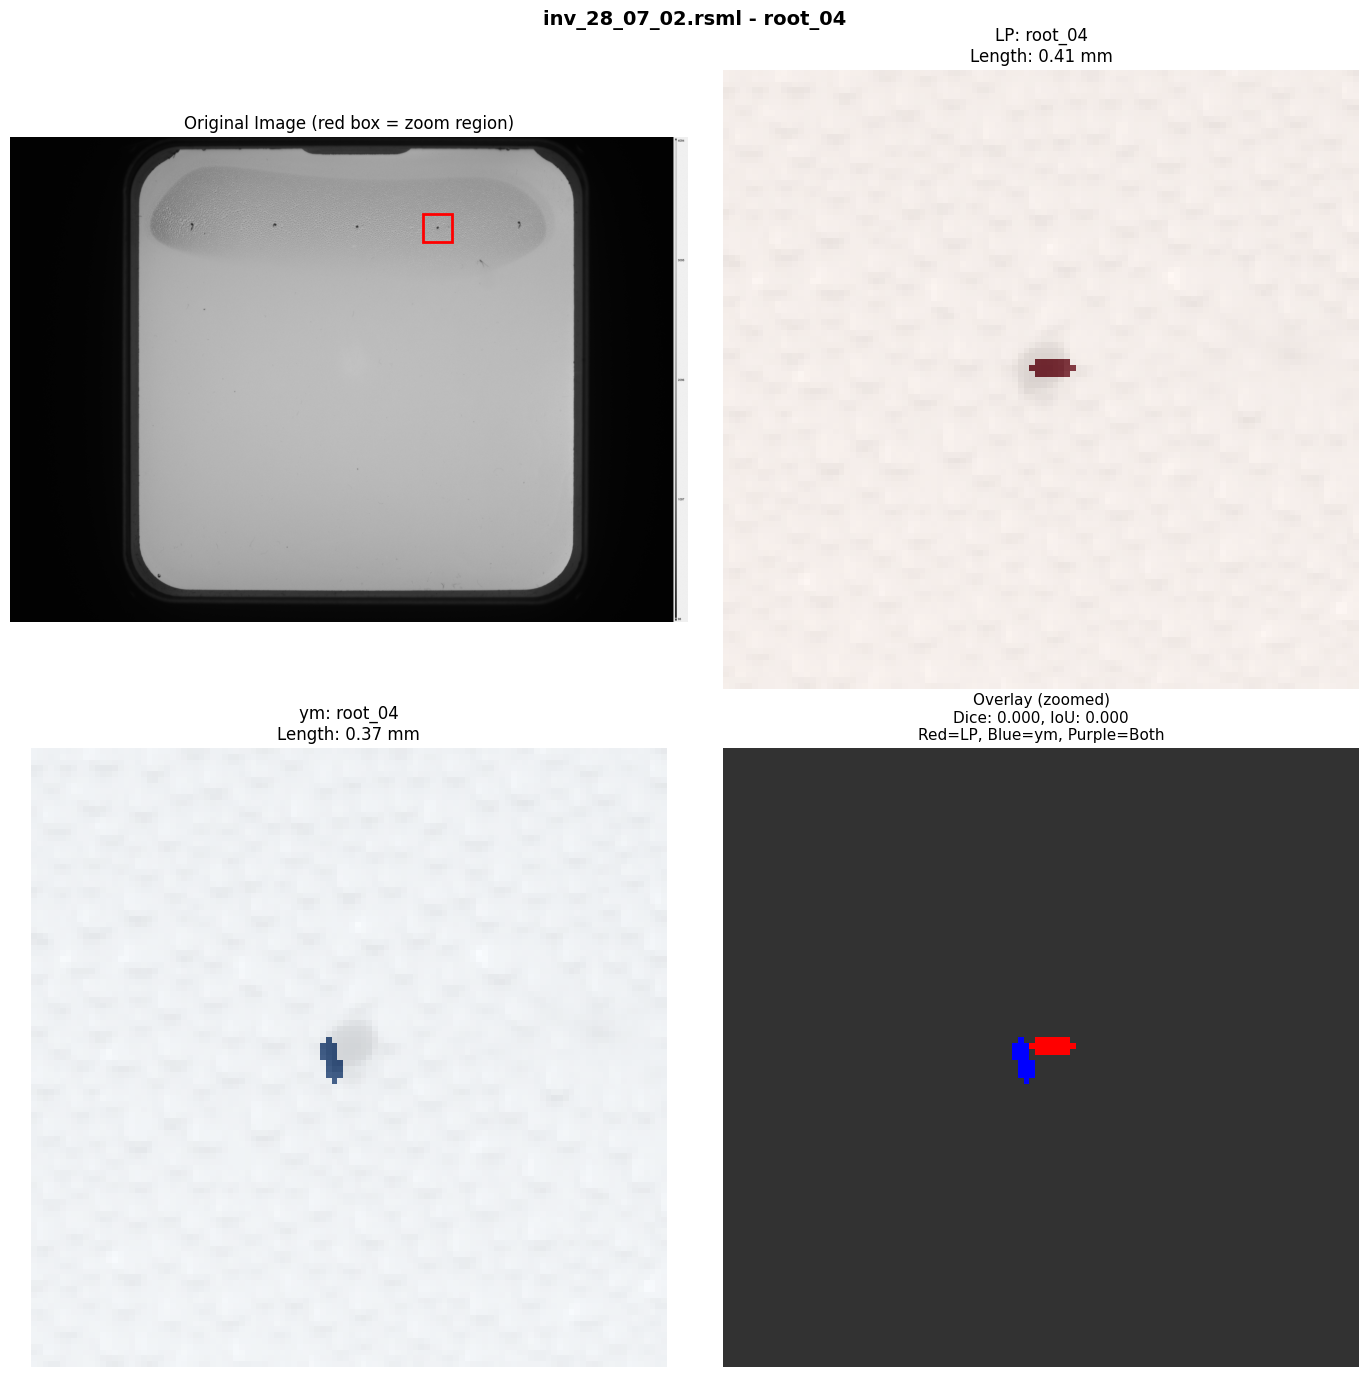


Case 6: Dice=0.276, Length diff=0.250 mm


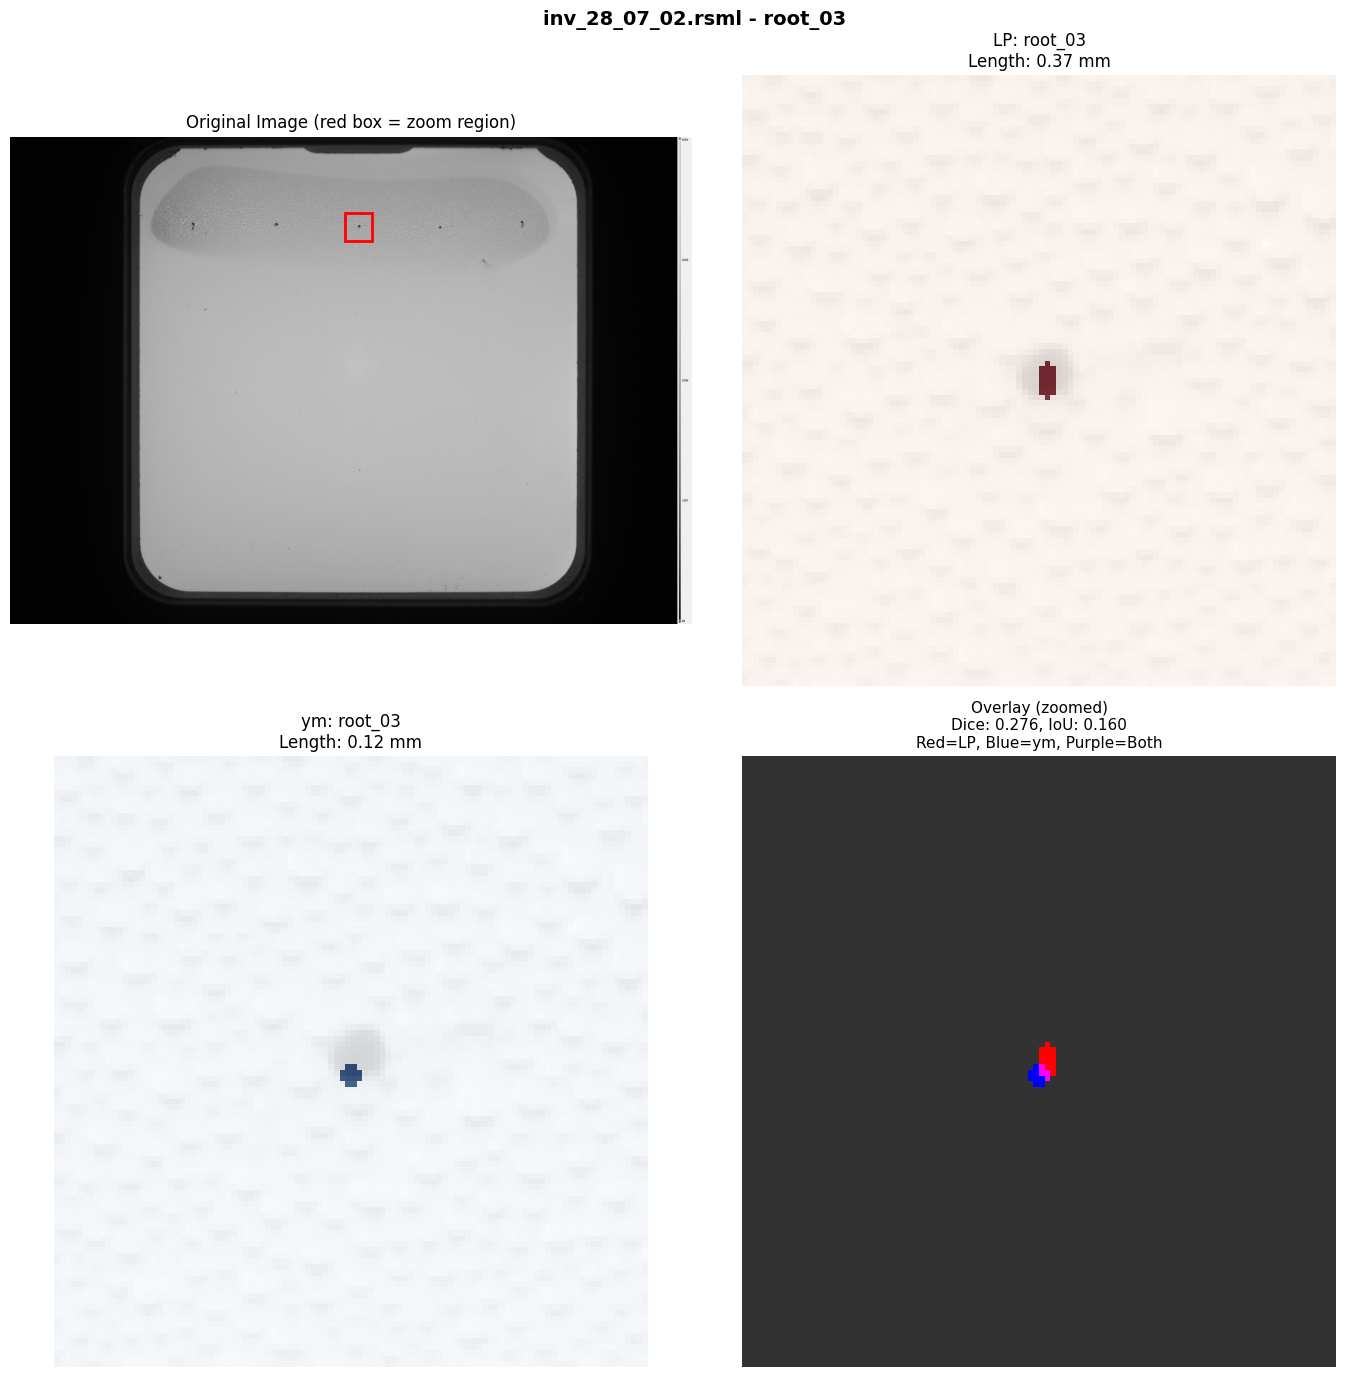


Case 5: Dice=0.638, Length diff=0.366 mm


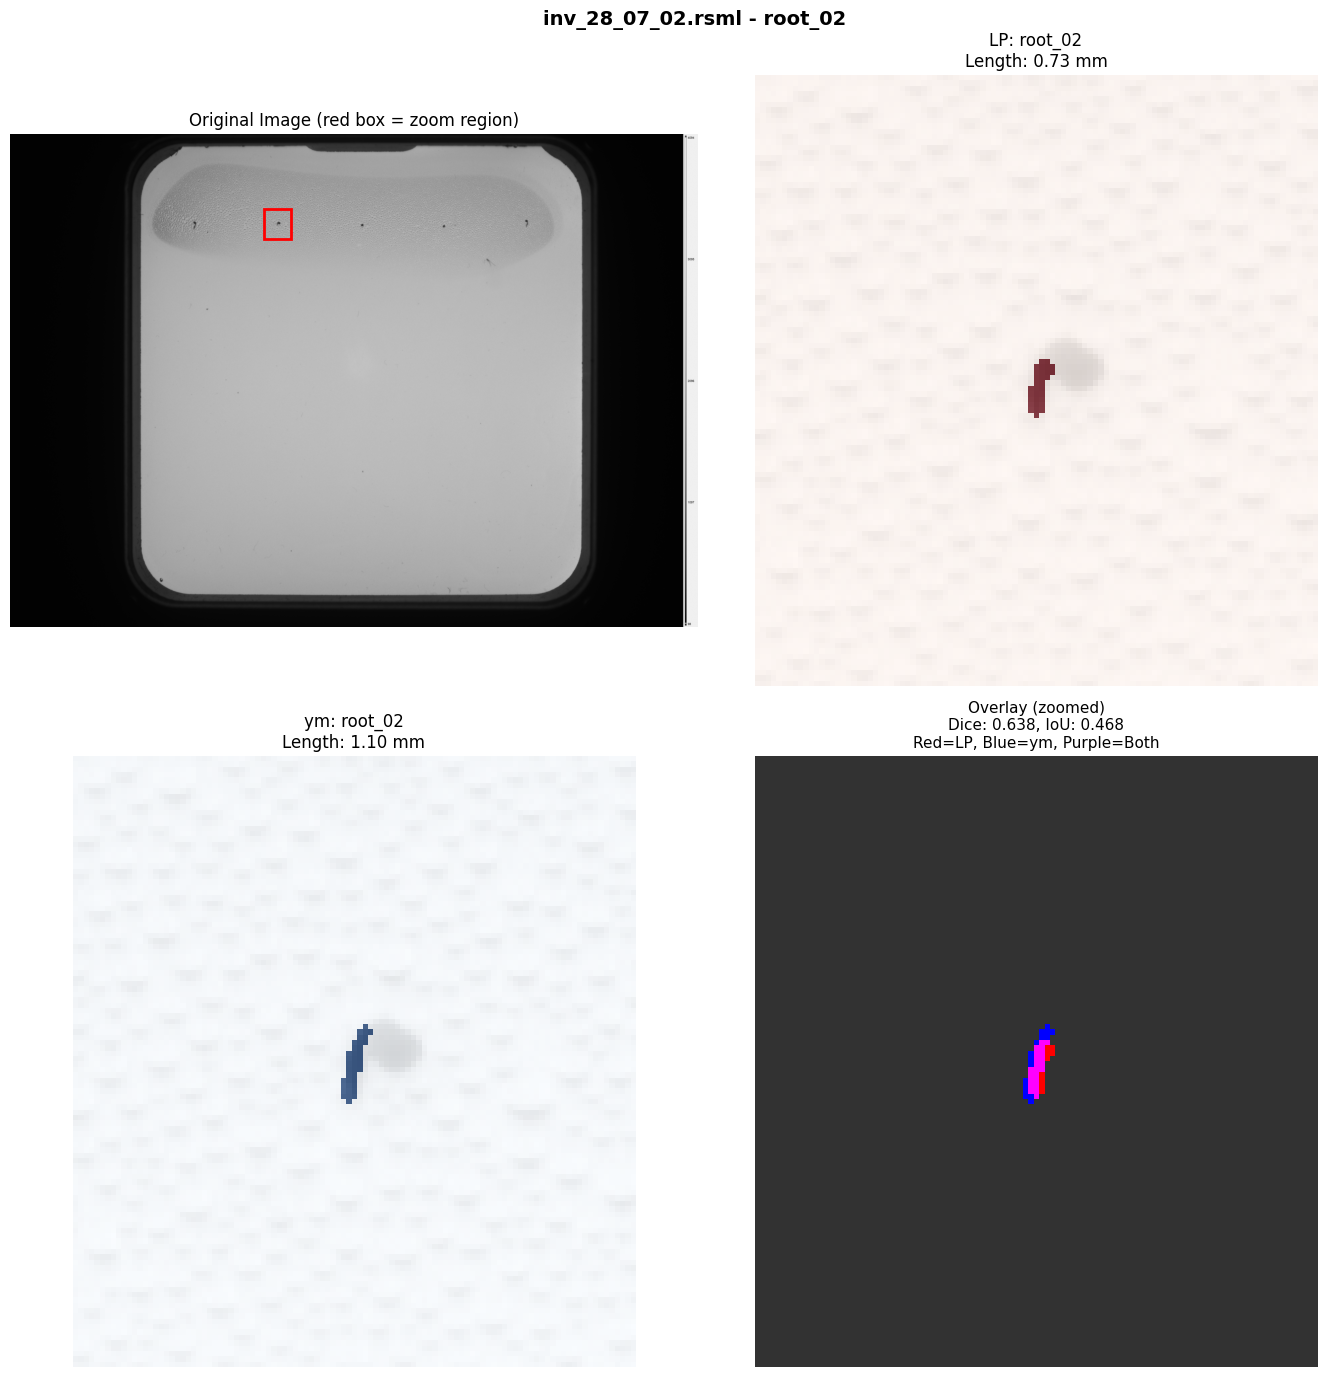


Case 24: Dice=0.711, Length diff=0.178 mm


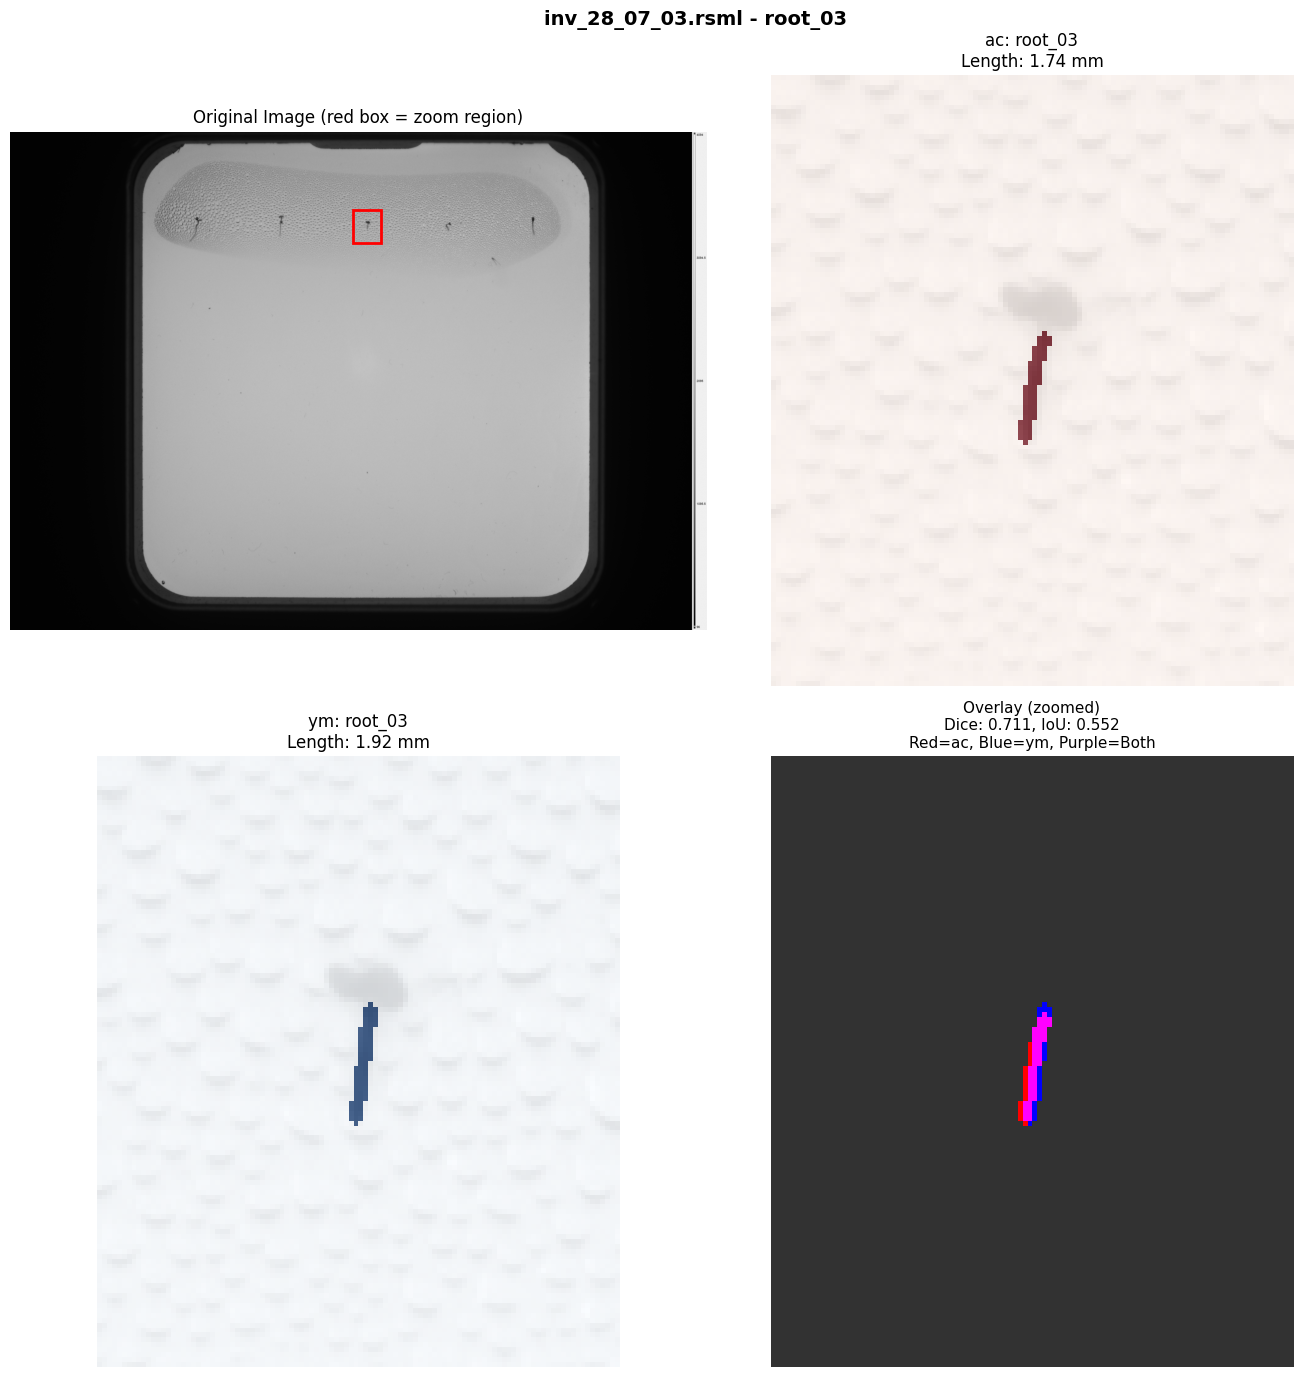


Case 19: Dice=0.714, Length diff=0.051 mm


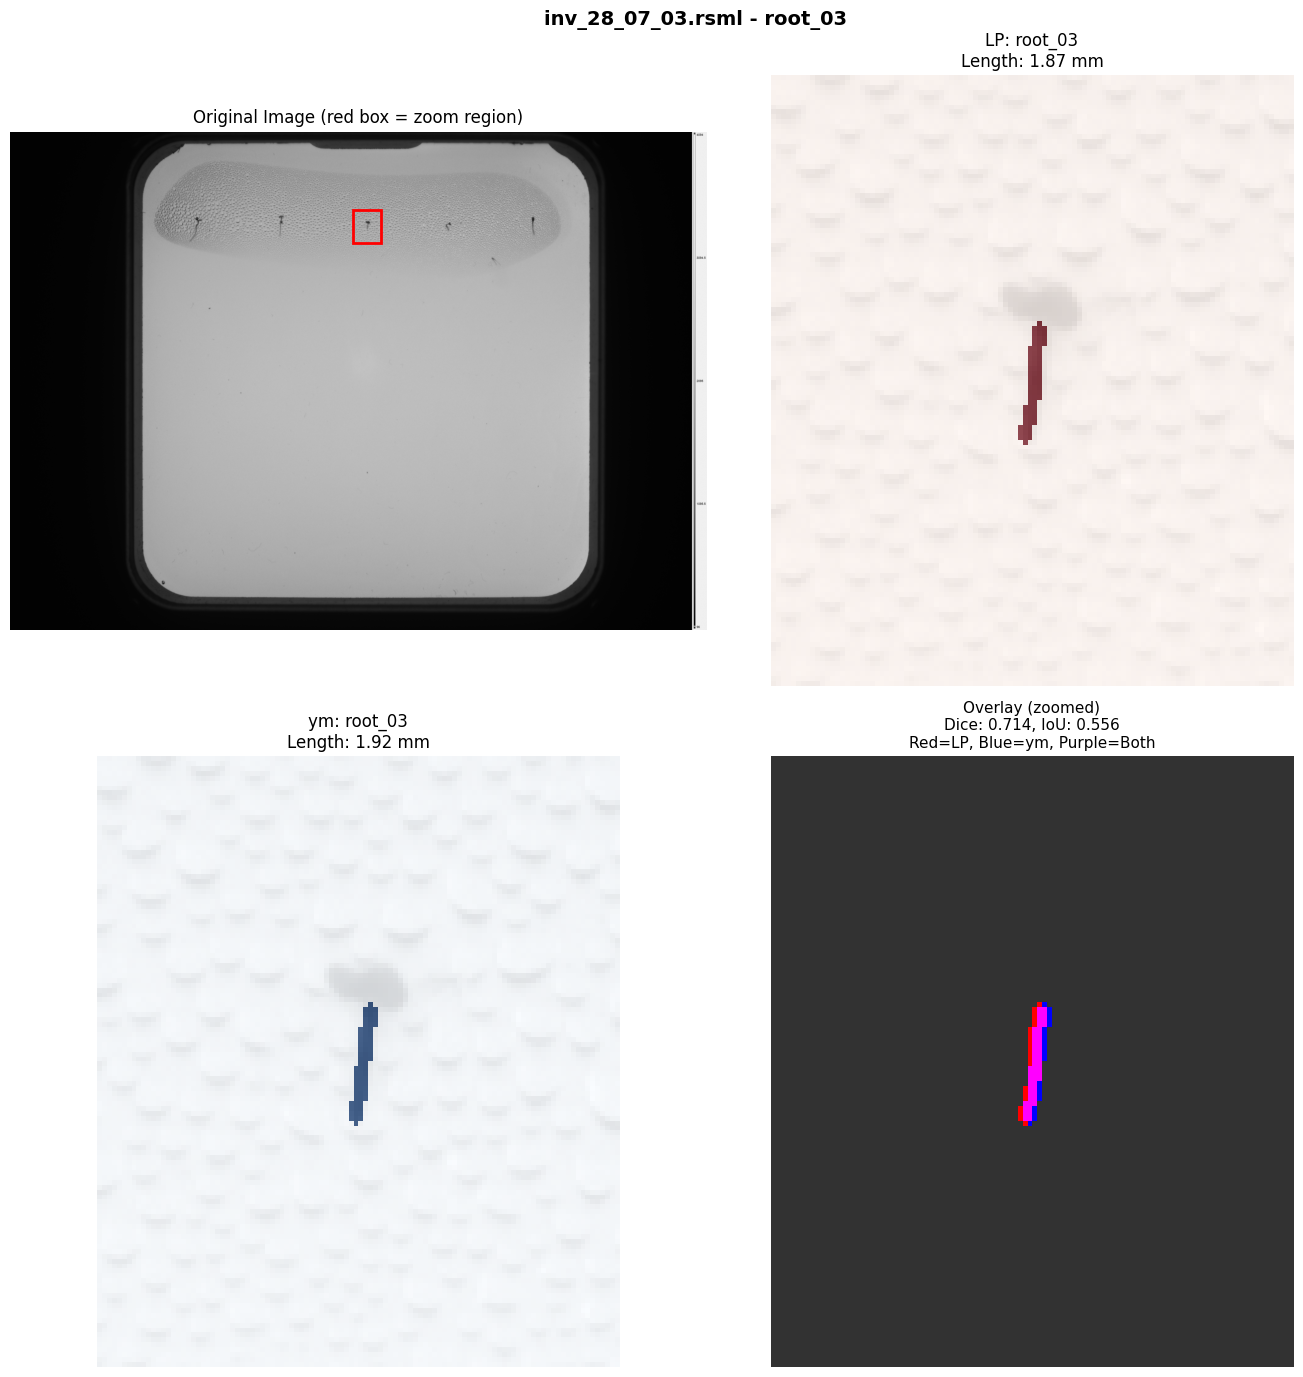

In [12]:
# Visualize the 5 worst overlaps
worst_cases = comparisons_with_masks.nsmallest(5, 'dice')

for idx, row in worst_cases.iterrows():
    print(f"\n{'='*60}")
    print(f"Case {idx+1}: Dice={row['dice']:.3f}, Length diff={row['abs_diff']:.3f} mm")
    visualize_mask_comparison(
        df_all, 
        row['filename'], 
        row['label'],
        row['annotator_a'],
        row['annotator_b'],
        image_dir
    )

## Export

In [16]:
!jupytext --to py './annotation_comparison.ipynb'

[jupytext] Reading ./annotation_comparison.ipynb in format ipynb
[jupytext] Writing ./annotation_comparison.py (destination file replaced)
